In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

file_path = "../examples/manipulation/resources/line_seg_mha/goals_map_cspace.txt"
data = np.genfromtxt(file_path, delimiter=",", dtype=float)

data = data[:, ~np.isnan(data).any(axis=0)]

(7200, 7)


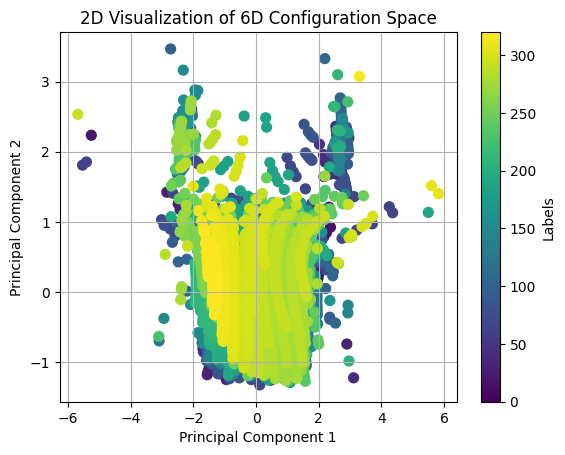

In [5]:

print(data.shape)

# Extract labels (first column) and configuration data (remaining columns)
labels = data[:, 0]
configurations = data[:, 1:]

# Perform PCA to reduce to 2D
pca = PCA(n_components=3)
data_2d = pca.fit_transform(configurations)

# Plot the 2D projection with colors based on labels
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='viridis', s=50)
plt.title('2D Visualization of 6D Configuration Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Labels')  # Add a color bar to show label mapping
plt.grid()
plt.show()


In [ ]:
data_3d = pca.fit_transform(configurations)

# Plot the 3D projection with colors based on labels
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], c=labels, cmap='viridis', s=50)
ax.set_title('3D Visualization of 6D Configuration Space')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
fig.colorbar(sc, label='Labels')  # Add a color bar to show label mapping
plt.show()

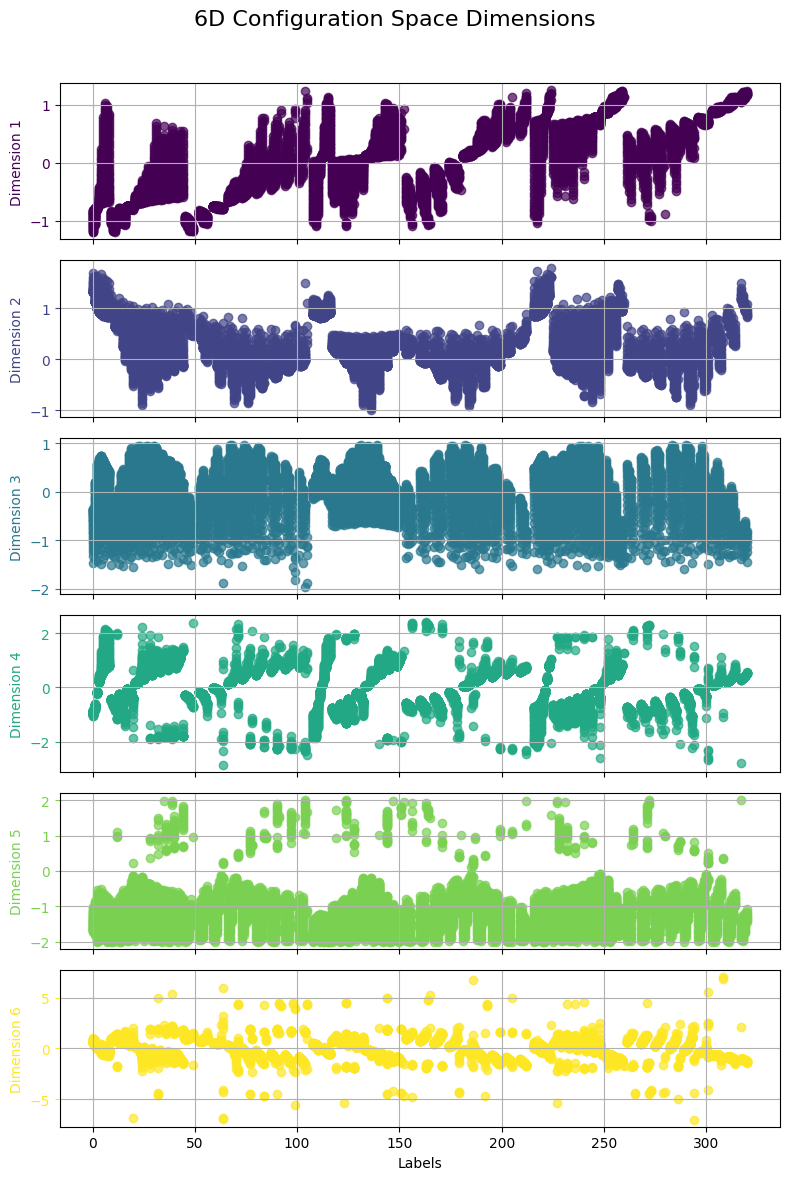

In [9]:
# Load data from the .txt file, handling trailing commas or spaces
try:
    # Use genfromtxt to load the data
    data = np.genfromtxt(file_path, delimiter=",", dtype=float)

    # Remove columns with NaN values caused by trailing delimiters
    data = data[:, ~np.isnan(data).any(axis=0)]

    # Check if the data is valid after processing
    if data.shape[1] < 7:  # Ensure there are at least 7 columns (label + 6 dimensions)
        raise ValueError("The input data does not have enough valid columns after cleaning.")

    # Extract labels (first column) and configuration data (remaining columns)
    labels = data[:, 0]
    configurations = data[:, 1:]

    # Number of dimensions
    num_dimensions = configurations.shape[1]

    # Define a color palette for the dimensions
    colors = plt.cm.viridis(np.linspace(0, 1, num_dimensions))

    # Create subplots for each dimension
    fig, axes = plt.subplots(num_dimensions, 1, figsize=(8, 12), sharex=True)

    for i in range(num_dimensions):
        axes[i].scatter(labels, configurations[:, i], c=[colors[i]], alpha=0.7)
        axes[i].set_ylabel(f"Dimension {i + 1}", color=colors[i])
        axes[i].tick_params(axis='y', colors=colors[i])  # Match tick colors to the plot
        axes[i].grid()

    # Set x-axis label on the last subplot
    axes[-1].set_xlabel("Labels")

    # Set overall title
    fig.suptitle("6D Configuration Space Dimensions", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
    plt.savefig("configssss.png", dpi=300)
    plt.show()


except IOError:
    print(f"Error: Could not read the file at {file_path}. Please check the file path.")
except ValueError as e:
    print(f"Error: {e}")

